<div align="center">

# Trabajo Práctico: Predicción de Precios de Casas

**Aprendizaje Automático 1 — Tecnicatura en Inteligencia Artificial (FCEIA)**

</div>

---

**Integrantes:** 
* Aiup, Agustín.
* Paoloni, Franco.
* Silva, Julián.

---

## Librerias y Dataset

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Mostramos todas las columnas y limitamos los decimales para que las tablas sean legibles.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Estilo uniforme para todos los gráficos del notebook.
sns.set_theme(style="whitegrid")

# Semilla global: la reutilizamos en cada paso aleatorio para que el trabajo sea reproducible.
RANDOM_STATE = 42

In [35]:
house_pricing = pd.read_csv(("../data/house-prices-tp.csv"))

## Análisis Exploratorio

En esta sección se elabora un primer diagnóstico del conjunto de datos.

### Estructura General

In [36]:
print(f"Dimensiones del Dataset: {house_pricing.shape[0]} filas x {house_pricing.shape[1]} columnas.")

Dimensiones del Dataset: 556 filas x 14 columnas.


In [37]:
house_pricing.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.072,0.000,4.490,0.000,0.449,6.121,56.800,3.748,3.000,247.000,18.500,395.150,8.440,22.200
1,0.083,0.000,13.920,0.000,0.437,6.127,18.400,5.503,4.000,289.000,16.000,396.900,8.580,23.900
2,0.128,12.500,6.070,0.000,0.409,5.885,33.000,6.498,4.000,345.000,18.900,396.900,8.790,20.900
3,0.089,21.000,5.640,0.000,0.439,5.963,45.700,6.815,4.000,243.000,16.800,395.560,13.450,19.700
4,0.114,0.000,8.560,0.000,0.520,6.781,71.300,2.856,5.000,384.000,20.900,395.580,7.670,26.500
5,0.063,0.000,11.930,0.000,0.573,6.593,69.100,2.479,1.000,273.000,21.000,391.990,9.670,22.400
6,0.358,0.000,6.200,1.000,0.507,6.951,88.500,2.862,8.000,307.000,17.400,391.700,9.710,26.700
7,0.088,0.000,10.810,0.000,0.413,6.417,6.600,5.287,4.000,305.000,19.200,383.730,6.720,24.200
8,1.355,0.000,8.140,0.000,0.538,6.072,100.000,4.175,4.000,307.000,21.000,376.730,13.040,14.500
9,0.303,0.000,7.380,0.000,0.493,6.312,28.900,5.416,5.000,287.000,19.600,396.900,6.150,23.000


In [38]:
house_pricing.tail(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
546,0.664,20.000,3.970,0.000,0.647,7.333,100.000,1.895,5.000,264.000,13.000,383.290,7.790,36.000
547,0.028,75.000,2.950,0.000,0.428,6.595,21.800,5.401,3.000,252.000,18.300,395.630,4.320,30.800
548,0.575,0.000,6.200,0.000,0.507,8.337,73.300,3.838,8.000,307.000,17.400,385.910,2.470,41.700
549,0.323,0.000,21.890,0.000,0.624,5.942,93.500,1.967,4.000,437.000,21.200,378.250,16.900,17.400
550,0.087,45.000,3.440,0.000,0.437,7.178,26.300,6.480,5.000,398.000,15.200,390.490,2.870,36.400
551,0.082,30.000,4.930,0.000,0.428,6.481,18.500,6.190,6.000,300.000,16.600,379.410,6.360,23.700
552,0.475,0.000,9.900,0.000,0.544,6.113,58.800,4.002,4.000,304.000,18.400,396.230,12.730,21.000
553,0.250,0.000,21.890,0.000,0.624,5.857,98.200,1.669,4.000,437.000,21.200,392.040,21.320,13.300
554,32.504,6.529,8.937,1.000,NaN,4.017,NaN,5.244,20.417,197.237,19.639,6.267,7.034,23.029
555,0.239,0.000,9.690,0.000,0.585,6.019,65.300,2.409,6.000,391.000,19.200,396.900,12.920,21.200


In [39]:
house_pricing.info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


Del análisis anterior se desprende la presencia de una gran cantidad de datos faltantes (causa del porque `pandas` no reconoce de manera efectiva los tipos de variables). Antes de seguir elaborando descripciones de los datos, se proecde a investigar estos datos nulos.

### Análisis de Valores Faltantes

Primero se eliminan las observación en donde `MEDV` tiene datos faltantes. Se procede de esta forma en lugar de imputar los datos, para no entrenar un modelo y estimar una variable con etiquetas no observadas.

In [40]:
print(f"La variable de respuesta 'MEDV' tiene {house_pricing['MEDV'].isna().sum()} datos faltantes.")

# Procedemos a eliminar los datos faltantes
house_pricing = house_pricing.dropna(subset = ['MEDV'])
print(f"\n El DataFrame ahora tiene {len(house_pricing)} observaciones.")

La variable de respuesta 'MEDV' tiene 21 datos faltantes.

 El DataFrame ahora tiene 535 observaciones.


Con el nuevo dataset, se analizan los datos que restan:

* Total de valores faltantes.
* Total de valores faltantes por variable (columnas).
* Total de valores faltantes por observacion (fila).


 Total de valores faltantes : 115

 Total de valores faltantes (por variable): 
   variable  nulos_x_variable  proporcion
0       RAD                12       2.243
1      CRIM                11       2.056
2       AGE                11       2.056
3        ZN                11       2.056
4      CHAS                 9       1.682
5       NOX                 9       1.682
6     LSTAT                 9       1.682
7         B                 9       1.682
8       TAX                 9       1.682
9   PTRATIO                 9       1.682
10       RM                 7       1.308
11      DIS                 5       0.935
12    INDUS                 4       0.748
13     MEDV                 0       0.000

 Total de filas con datos faltantes: 29

 Filas con datos faltantes: 
     nro_fila  nulos_x_obs  proporcion
0         88            9      69.231
1        248            8      61.538
2        504            8      61.538
3        223            7      53.846
4        234            7  

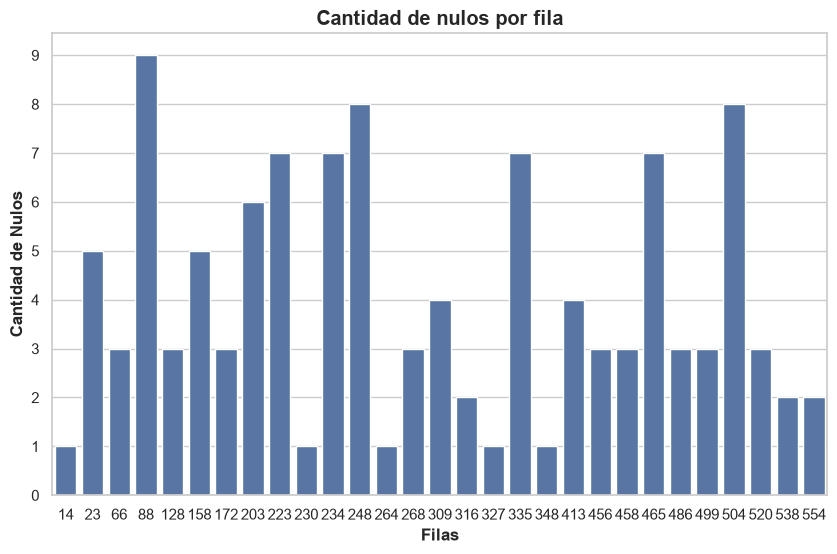

In [41]:
# Total de valores faltantes
total_nulos = (house_pricing.isna().sum().sum())

# Total de valores faltantes por variable (columnas):
total_nulos_variable = pd.DataFrame({
    'nulos_x_variable' : house_pricing.isna().sum(),
    'proporcion' : ((house_pricing.isna().sum() / len(house_pricing)) * 100)
    }).sort_values(by = 'proporcion', ascending = False)

total_nulos_variable = total_nulos_variable.reset_index()
total_nulos_variable = total_nulos_variable.rename(columns = {'index' : 'variable'})

# Total de valores faltantes por observación (filas):
total_nulos_filas = pd.DataFrame({
    'nulos_x_obs' : house_pricing.isna().sum(axis = 1),
    'proporcion' :  ((house_pricing.isna().sum(axis = 1) / 13)*100)
}).sort_values(by = 'proporcion', ascending = False)

total_nulos_filas = total_nulos_filas[total_nulos_filas['proporcion'] > 0]
total_nulos_filas = total_nulos_filas.reset_index()
total_nulos_filas = total_nulos_filas.rename(columns = {'index' : 'nro_fila'})


print(f"\n Total de valores faltantes : {total_nulos}")
print(f"\n Total de valores faltantes (por variable): \n{total_nulos_variable}")
print(f"\n Total de filas con datos faltantes: {len(total_nulos_filas)}")
print(f"\n Filas con datos faltantes: \n {total_nulos_filas}")
print(f"\n Promedio de faltantes por fila: {round(total_nulos_filas['nulos_x_obs'].mean(), 0)}")


# Graficamos la cantidad de las filas con faltantes

y_ticks = np.arange(0, 10, 1)

fig, ax = plt.subplots(figsize = (10, 6))
sns.barplot(total_nulos_filas, x = 'nro_fila', y = 'nulos_x_obs')
ax.set_title('Cantidad de nulos por fila', fontweight = 'bold', size = 'large')
ax.set_xlabel('Filas', fontweight = 'bold')
ax.set_ylabel('Cantidad de Nulos', fontweight = 'bold')
ax.set_yticks(y_ticks)
plt.show()

Se observa que 29 filas de 535 presentan valores faltantes (aprox. 5% de las observaciones restantes). A su vez, en promedio, faltan 4 de las 13 variables predictoras por fila, es decir casi un tercio de cada observación afectada.

Imputar consiste en estimar el valor faltante a partir del resto de la información de esa misma fila y del conjunto. Con ese nivel de deterioro queda poca información sobre la cual apoyar la estimación: esas filas entrarían al modelo con más valores construidos por nosotros que medidos, y pesarían igual que las reales durante el ajuste. Como además representan apenas el 5% de los datos, el costo de eliminarlas es bajo frente al riesgo de sesgar el modelo imputándolas.

In [42]:
house_pricing = house_pricing.dropna().reset_index(drop = True)

print(f"El DataFrame ahora quedó con {house_pricing.shape[0]} observaciones y {house_pricing.shape[1]} variables.")

El DataFrame ahora quedó con 506 observaciones y 14 variables.


### Estadísticas Descriptivas (post Tratmiento de Datos Faltantes)

In [43]:
house_pricing.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.072,0.000,4.490,0.000,0.449,6.121,56.800,3.748,3.000,247.000,18.500,395.150,8.440,22.200
1,0.083,0.000,13.920,0.000,0.437,6.127,18.400,5.503,4.000,289.000,16.000,396.900,8.580,23.900
2,0.128,12.500,6.070,0.000,0.409,5.885,33.000,6.498,4.000,345.000,18.900,396.900,8.790,20.900
3,0.089,21.000,5.640,0.000,0.439,5.963,45.700,6.815,4.000,243.000,16.800,395.560,13.450,19.700
4,0.114,0.000,8.560,0.000,0.520,6.781,71.300,2.856,5.000,384.000,20.900,395.580,7.670,26.500
5,0.063,0.000,11.930,0.000,0.573,6.593,69.100,2.479,1.000,273.000,21.000,391.990,9.670,22.400
6,0.358,0.000,6.200,1.000,0.507,6.951,88.500,2.862,8.000,307.000,17.400,391.700,9.710,26.700
7,0.088,0.000,10.810,0.000,0.413,6.417,6.600,5.287,4.000,305.000,19.200,383.730,6.720,24.200
8,1.355,0.000,8.140,0.000,0.538,6.072,100.000,4.175,4.000,307.000,21.000,376.730,13.040,14.500
9,0.303,0.000,7.380,0.000,0.493,6.312,28.900,5.416,5.000,287.000,19.600,396.900,6.150,23.000


In [44]:
house_pricing.tail(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
496,0.051,0.000,5.190,0.000,0.515,6.316,38.100,6.458,5.000,224.000,20.200,389.710,5.680,22.200
497,0.664,20.000,3.970,0.000,0.647,7.333,100.000,1.895,5.000,264.000,13.000,383.290,7.790,36.000
498,0.028,75.000,2.950,0.000,0.428,6.595,21.800,5.401,3.000,252.000,18.300,395.630,4.320,30.800
499,0.575,0.000,6.200,0.000,0.507,8.337,73.300,3.838,8.000,307.000,17.400,385.910,2.470,41.700
500,0.323,0.000,21.890,0.000,0.624,5.942,93.500,1.967,4.000,437.000,21.200,378.250,16.900,17.400
501,0.087,45.000,3.440,0.000,0.437,7.178,26.300,6.480,5.000,398.000,15.200,390.490,2.870,36.400
502,0.082,30.000,4.930,0.000,0.428,6.481,18.500,6.190,6.000,300.000,16.600,379.410,6.360,23.700
503,0.475,0.000,9.900,0.000,0.544,6.113,58.800,4.002,4.000,304.000,18.400,396.230,12.730,21.000
504,0.250,0.000,21.890,0.000,0.624,5.857,98.200,1.669,4.000,437.000,21.200,392.040,21.320,13.300
505,0.239,0.000,9.690,0.000,0.585,6.019,65.300,2.409,6.000,391.000,19.200,396.900,12.920,21.200


Teniendo en cuenta la naturaleza de las variables `CHAS`, `RAD` y `TAX`, se procede a modificar el tipo de dato.

In [45]:
house_pricing['CHAS'] = house_pricing['CHAS'].astype('category')
house_pricing['RAD'] = house_pricing['RAD'].astype('int64')
house_pricing['TAX'] = house_pricing['TAX'].astype('int64')

house_pricing.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    int64   
 9   TAX      506 non-null    int64   
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(1), float64(11), int64(2)
memory usage: 52.0 KB


Se analizan las principales medidas y se grafican las distribuciones.

In [46]:
house_pricing.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000
mean,3.614,11.364,11.137,0.555,6.285,68.575,3.795,9.549,408.237,18.456,356.674,12.653,22.533
std,8.602,23.322,6.860,0.116,0.703,28.149,2.106,8.707,168.537,2.165,91.295,7.141,9.197
min,0.006,0.000,0.460,0.385,3.561,2.900,1.130,1.000,187.000,12.600,0.320,1.730,5.000
25%,0.082,0.000,5.190,0.449,5.885,45.025,2.100,4.000,279.000,17.400,375.377,6.950,17.025
50%,0.257,0.000,9.690,0.538,6.208,77.500,3.207,5.000,330.000,19.050,391.440,11.360,21.200
75%,3.677,12.500,18.100,0.624,6.623,94.075,5.188,24.000,666.000,20.200,396.225,16.955,25.000
max,88.976,100.000,27.740,0.871,8.780,100.000,12.127,24.000,711.000,22.000,396.900,37.970,50.000


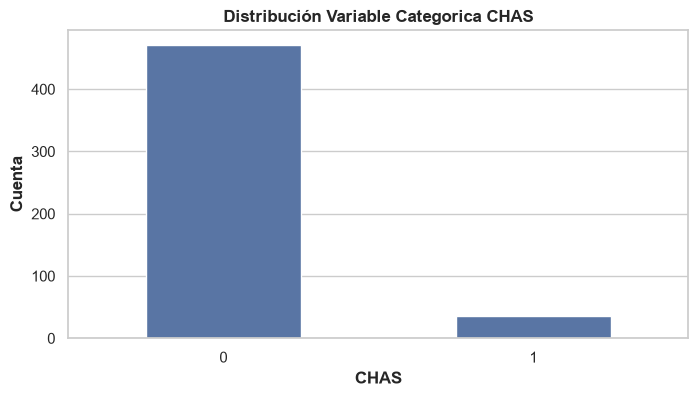

In [47]:
fig, ax = plt.subplots(figsize = (8, 4))

sns.countplot(house_pricing, x = 'CHAS', width = 0.5)
ax.set_title('Distribución Variable Categorica CHAS', fontweight = 'bold')
ax.set_xlabel('CHAS', fontweight = 'bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['0', '1'])
ax.set_ylabel('Cuenta', fontweight = 'bold')
plt.show()

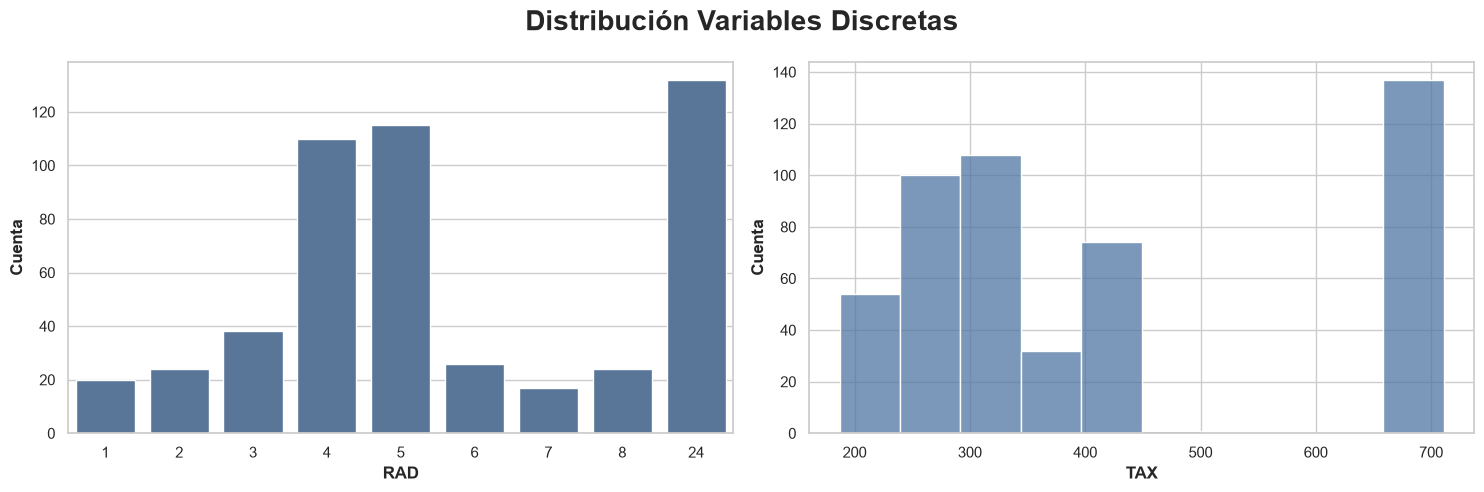

In [48]:
columnas_discretas = ['RAD', 'TAX']

fig, axes = plt.subplots(ncols = 2, nrows = 1, figsize = (15, 5))
axes = axes.flatten()

for columna, ax in zip(columnas_discretas, axes):
    if columna == 'TAX':
        sns.histplot(house_pricing, x = columna, ax=ax, kde = False, color = '#4f75a2')
        ax.set_xlabel(columna, fontweight = 'bold')
    else:
        sns.countplot(house_pricing, x = columna, ax = ax, color = '#4f75a2')
        ax.set_xlabel(columna, fontweight = 'bold')

    ax.set_ylabel("Cuenta", fontweight = 'bold', fontsize = 12)


plt.suptitle('Distribución Variables Discretas', fontweight = 'bold', fontsize = 20)
plt.tight_layout()
plt.show()

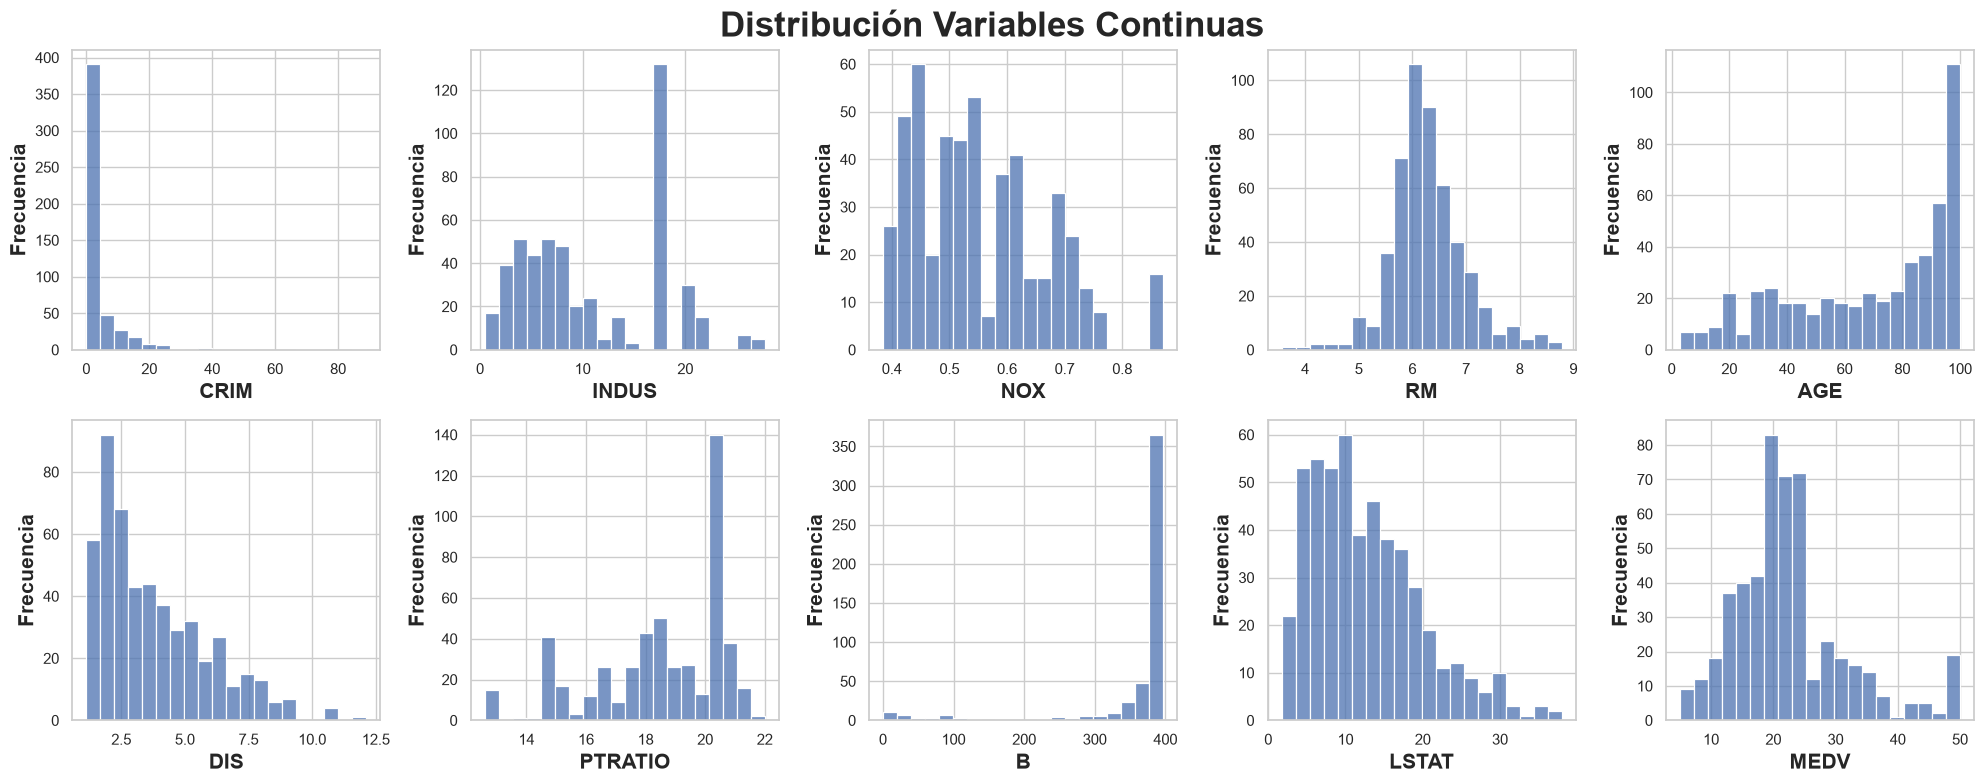

In [49]:
columnas_histograma = []

for columna in house_pricing.columns:
    if columna not in ['ZN', 'CHAS', 'RAD', 'TAX']:
        columnas_histograma.append(columna)


fig, axes = plt.subplots(ncols = 5, nrows = 4, figsize = (20, 15))
axes = axes.flatten()

for ax, columna in zip(axes, columnas_histograma):
    sns.histplot(house_pricing, x = columna, ax = ax, bins = 20)
    ax.set_ylabel('Frecuencia', fontweight = 'bold', fontsize = 15)
    ax.set_xlabel(columna, fontweight = 'bold', fontsize = 15)


for i in range(len(columnas_histograma), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Distribución Variables Continuas', fontweight = 'bold', fontsize = 25)
plt.tight_layout()
plt.show()


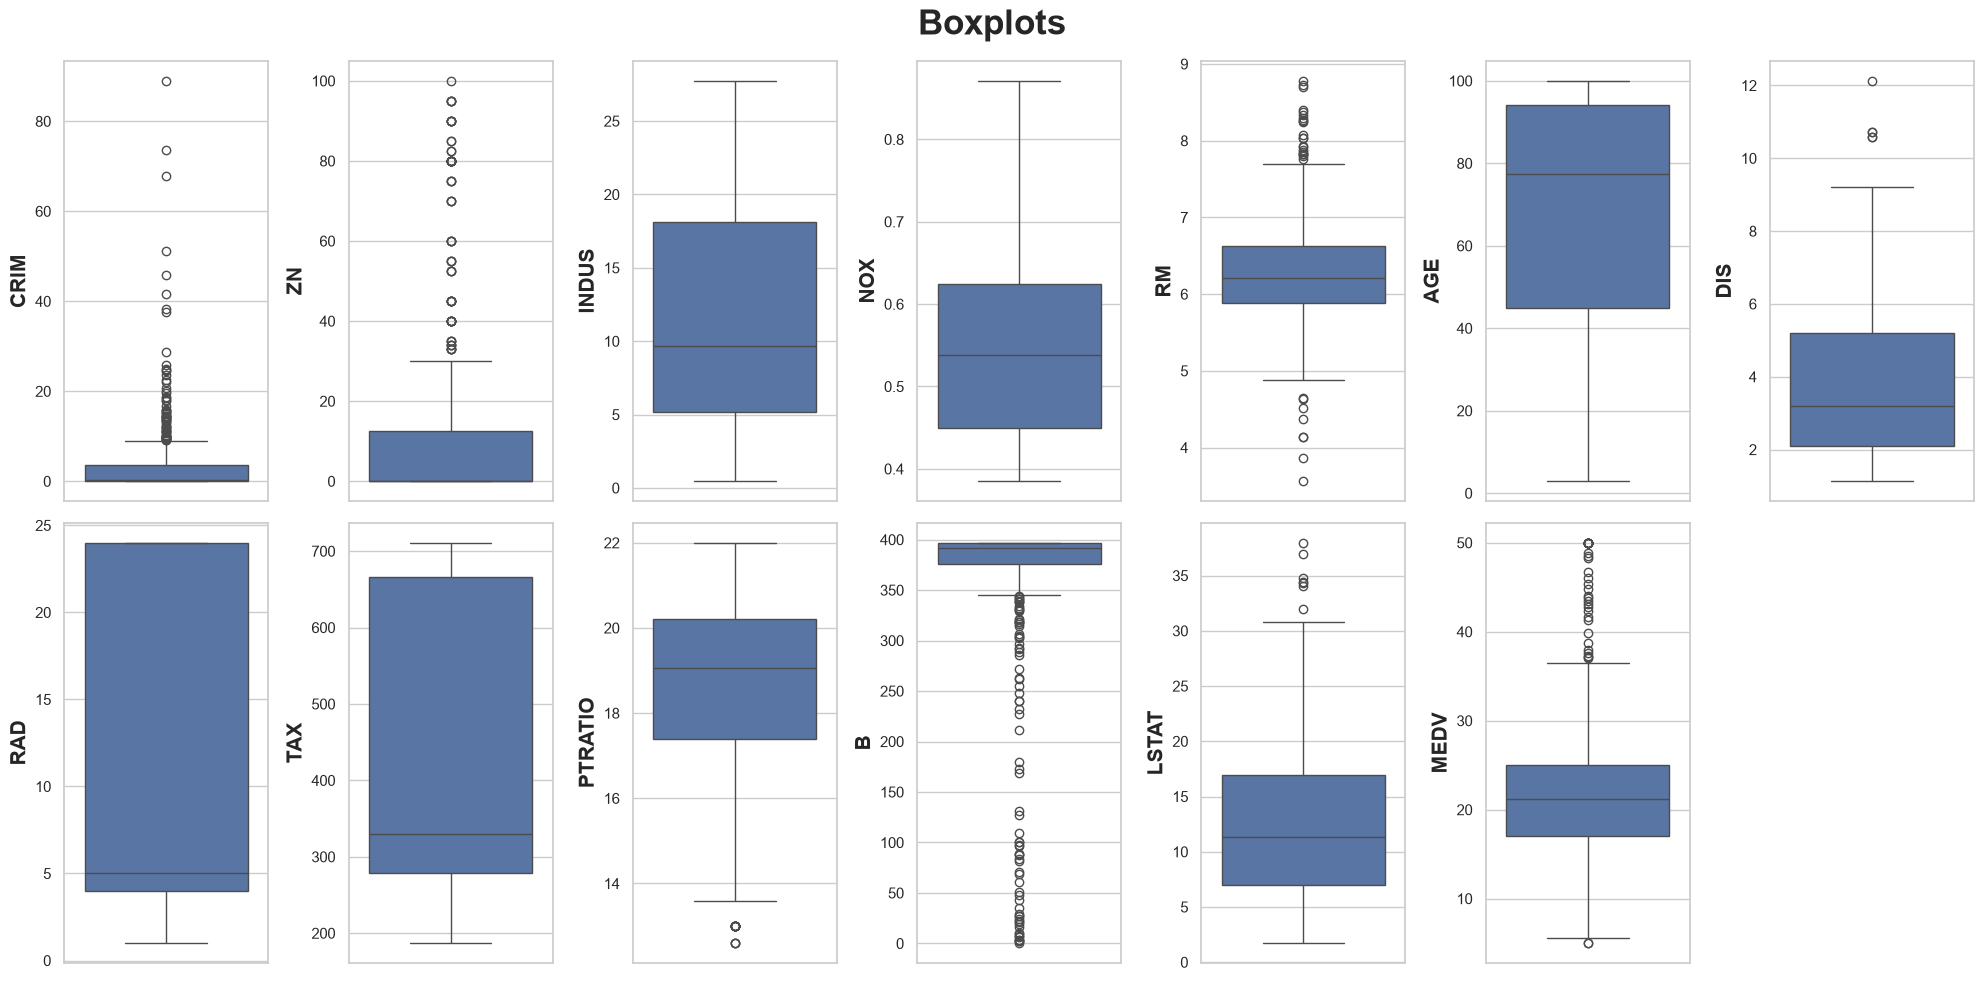

In [50]:
columnas_boxplot = []

for columna in house_pricing.columns:
    if columna != 'CHAS':
        columnas_boxplot.append(columna)

fig, axes = plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
axes = axes.flatten()

for ax, columna in zip(axes, columnas_boxplot):
    sns.boxplot(data=house_pricing, y=columna, ax=ax)
    ax.set_ylabel(columna, fontweight = 'bold', fontsize = 15)


fig.delaxes(axes[13])
fig.suptitle('Boxplots', fontweight = 'bold', fontsize = 25)
plt.tight_layout()
plt.show()

### Análisis de Outliers

Los boxplots de la sección anterior muestran valores alejados del cuerpo de cada distribución. Para determinar que datos serían considerados _outliers_, se aplica el criterio del rango intercuartílico (IQR). se consideran atípicos los valores que caen a más de 1,5 IQR por debajo del primer cuartil o por encima del tercero.

In [51]:
columnas_iqr = []
for columna in house_pricing.columns:
    if columna != 'CHAS':
        columnas_iqr.append(columna)

conteo_outliers = []

for columna in columnas_iqr:
    q1 = house_pricing[columna].quantile(0.25)
    q3 = house_pricing[columna].quantile(0.75)
    iqr = q3 - q1

    fuera_de_rango = (house_pricing[columna] < q1 - 1.5 * iqr) | (house_pricing[columna] > q3 + 1.5 * iqr)

    conteo_outliers.append({
        'variable' : columna,
        'outliers' : fuera_de_rango.sum(),
        'proporcion' : (fuera_de_rango.sum() / len(house_pricing)) * 100,
        'asimetria' : house_pricing[columna].skew()
    })

# Se ordena de mayor a menor cantidad de atípicos y se agrega la asimetría para interpretarlos.
outliers_iqr = pd.DataFrame(conteo_outliers).sort_values(by = 'outliers', ascending = False).reset_index(drop = True)

print(f"\n Outliers por variable (criterio IQR): \n{outliers_iqr}")


 Outliers por variable (criterio IQR): 
   variable  outliers  proporcion  asimetria
0         B        77      15.217     -2.890
1        ZN        68      13.439      2.226
2      CRIM        66      13.043      5.223
3      MEDV        40       7.905      1.108
4        RM        30       5.929      0.404
5   PTRATIO        15       2.964     -0.802
6     LSTAT         7       1.383      0.906
7       DIS         5       0.988      1.012
8     INDUS         0       0.000      0.295
9       NOX         0       0.000      0.729
10      TAX         0       0.000      0.670
11      AGE         0       0.000     -0.599
12      RAD         0       0.000      1.005


A pensar de que algunas variables muestran gran cantidad de _outliers_, conviene hacer un análisis antes de decidir que hacer.

En `CRIM` la asimetría es 5,22: la mediana es 0,26 y el máximo 88,98. Se trata de una cola larga, no de errores de medición: hay pocos barrios con criminalidad muy alta y son justamente los que explican los precios más bajos.

En `ZN`, el 74% de las observaciones tiene `ZN` = 0, de modo que los cuartiles quedan muy juntos y cualquier municipio con zonificación amplia cae fuera del límite. En `B` ocurre algo similar: los valores se concentran cerca del techo de la variable y el rango intercuartílico es de apenas 21 puntos.

Por último, 16 de los 40 atípicos de `MEDV` valen exactamente 50,0, que es el máximo de la variable. El precio está censurado en ese tope, lo que acota el desempeño alcanzable en el extremo superior y se retomará al analizar los residuos.

Eliminar las observaciones marcadas implicaría descartar los barrios de mayor criminalidad, los de zonificación amplia y las viviendas más caras, es decir buena parte de la variabilidad que el modelo necesita. Por lo tanto los valores atípicos se documentan y se tienen en cuenta en la interpretación, pero no se eliminan.

### Matriz de Correlación

Se realiza un análisis de correlación para identificar qué predictoras se asocian con `MEDV` y detectar asociaciones fuertes entre predictoras.

Primero se realiza una matriz de correlacion de Pearson.

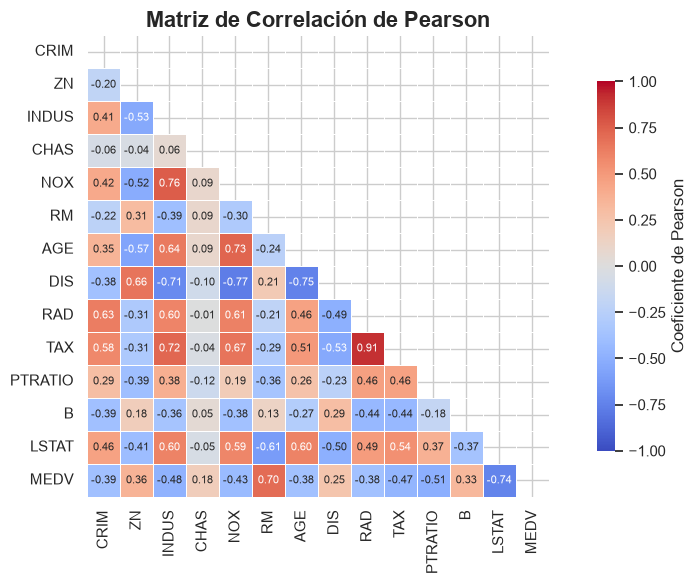

In [52]:
# Se vuelve a pasar la variable CHAS a entero
house_pricing['CHAS'] = house_pricing['CHAS'].astype('int64')

matriz_correlacion = house_pricing.corr(method = 'pearson')

# Se enmascara el triángulo superior para no repetir cada coeficiente dos veces.
mascara = np.triu(np.ones_like(matriz_correlacion, dtype = bool))

fig, ax = plt.subplots(figsize = (10, 6))

sns.heatmap(matriz_correlacion, mask = mascara, annot = True, fmt = '.2f',
            annot_kws = {'size' : 8}, cmap = 'coolwarm', vmin = -1, vmax = 1,
            center = 0, square = True, linewidths = 0.5,
            cbar_kws = {'shrink' : 0.8, 'label' : 'Coeficiente de Pearson'}, ax = ax)

ax.set_title('Matriz de Correlación de Pearson', fontweight = 'bold', fontsize = 16)
plt.tight_layout()
plt.show()

Se observa que `LSTAT` (−0,74) y `RM` (0,70) son las únicas dos que alcanzan 0,70 en valor absoluto, seguidas por `PTRATIO` (−0,51), `INDUS` (−0,48) y `TAX` (−0,47). En el extremo opuesto, `CHAS` (0,18) y `DIS` (0,25) prácticamente no presentan asociación lineal con el precio.

POr otro lado, si se ve que varias predictoras están fuertemente correlacionadas entre sí. El caso extremo es `RAD`–`TAX` (0,91), consistente con la bimodalidad de ambas variables. A ese par se suman `NOX`–`DIS` (−0,77), `INDUS`–`NOX` (0,76), `AGE`–`DIS` (−0,75), `NOX`–`AGE` (0,73), `INDUS`–`TAX` (0,72) e `INDUS`–`DIS` (−0,71).

Este fenómeno se explica por la mera naturaleza de los datos, ya que nos encontramos con un grupo de variables que describen un mismo fenómeno: zonas industriales, antiguas, contaminadas y próximas a los centros de empleo.

#### Contraste con el coeficiente de Spearman

Ahora se procede a comparar el coeficiente de correlación de Pearson entre las variables predictoras y la de respuesta, con el coeficiente de correlación de Spearman. Comparar ambas magnitudes permite estimar cuánta asociación quedará fuera del alcance de un modelo lineal.

In [53]:
# Pearson mide asociación lineal y Spearman monotonía: comparar ambos revela relaciones curvas.
correlacion_pearson = house_pricing.corr(method = 'pearson')['MEDV'].drop('MEDV')
correlacion_spearman = house_pricing.corr(method = 'spearman')['MEDV'].drop('MEDV')

comparacion_correlaciones = pd.DataFrame({
    'pearson' : correlacion_pearson,
    'spearman' : correlacion_spearman
})

# Diferencia entre magnitudes: cuanto mayor es, más asociación queda fuera del alcance de una recta.
comparacion_correlaciones['diferencia'] = (comparacion_correlaciones['spearman'].abs()
                                           - comparacion_correlaciones['pearson'].abs())

# Se ordena por la magnitud de Pearson para leer primero las predictoras más fuertes del modelo lineal.
orden_pearson = comparacion_correlaciones['pearson'].abs().sort_values(ascending = False).index
comparacion_correlaciones = comparacion_correlaciones.reindex(orden_pearson)

print(f"\n Correlación con MEDV (Pearson vs. Spearman): \n{comparacion_correlaciones}")


 Correlación con MEDV (Pearson vs. Spearman): 
         pearson  spearman  diferencia
LSTAT     -0.738    -0.853       0.115
RM         0.695     0.634      -0.062
PTRATIO   -0.508    -0.556       0.048
INDUS     -0.484    -0.578       0.095
TAX       -0.469    -0.562       0.094
NOX       -0.427    -0.563       0.135
CRIM      -0.388    -0.559       0.171
RAD       -0.382    -0.347      -0.035
AGE       -0.377    -0.548       0.171
ZN         0.360     0.438       0.078
B          0.333     0.186      -0.148
DIS        0.250     0.446       0.196
CHAS       0.175     0.141      -0.035


El contraste no muestra diferencias marcadas entre ambos coeficientes. Las mayores brechas se dan en DIS (0,250 contra 0,446), AGE (−0,377 contra −0,548), CRIM (−0,388 contra −0,559) y NOX (−0,427 contra −0,563), pero en todos los casos se mantiene el orden de magnitud.

### Codificación de Variables Categóricas

En este dataset las 13 predictoras ya son numéricas, por lo que no hay que codificar variables categóricas.

### División en Conjuntos de Entrenamiento y Prueba

Se reserva el 20%de las observaciones para prueba y se entrena con el 80% restante.

Se procede a realizar la división antes de proceder con el escalado de las variables, para evitar el *data leakage*.

Se emplea `RANDOM_STATE` para que la partición sea reproducible y todos los modelos se comparen sobre exactamente los mismos conjuntos.

In [54]:
from sklearn.model_selection import train_test_split

# Se separan las 13 predictoras (X) de la variable de respuesta (y).
X = house_pricing.drop(columns = 'MEDV')
y = house_pricing['MEDV']

# El 20% se reserva para prueba y no se usa hasta la evaluación final.
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = RANDOM_STATE)

print(f"Entrenamiento: {X_train.shape[0]} filas y {X_train.shape[1]} predictoras")
print(f"Prueba:        {X_test.shape[0]} filas y {X_test.shape[1]} predictoras")

Entrenamiento: 404 filas y 13 predictoras
Prueba:        102 filas y 13 predictoras


### Escalado de Variables

Se procede a escalar las variables en el set de entrenamiento utilizando `StandarScaler`.

In [55]:
from sklearn.preprocessing import StandardScaler

escalador = StandardScaler()

X_train_escalado = escalador.fit_transform(X_train)
X_test_escalado = escalador.transform(X_test)

# Se comprueba el resultado: el train queda centrado en 0 con desvío 1 y el test no, como se esperaba.
resumen_escalado = pd.DataFrame({
    'media_train' : X_train_escalado.mean(axis = 0),
    'desvio_train' : X_train_escalado.std(axis = 0),
    'media_test' : X_test_escalado.mean(axis = 0),
    'desvio_test' : X_test_escalado.std(axis = 0)
}, index = X_train.columns)

print(f"\n Media y desvío por variable después del escalado: \n{resumen_escalado}")


 Media y desvío por variable después del escalado: 
         media_train  desvio_train  media_test  desvio_test
CRIM          -0.000         1.000      -0.057        0.585
ZN             0.000         1.000      -0.112        0.802
INDUS         -0.000         1.000       0.109        0.985
CHAS          -0.000         1.000       0.205        1.312
NOX           -0.000         1.000       0.085        0.927
RM            -0.000         1.000      -0.189        0.817
AGE            0.000         1.000       0.125        0.986
DIS            0.000         1.000      -0.088        0.921
RAD           -0.000         1.000       0.102        1.036
TAX           -0.000         1.000       0.053        1.025
PTRATIO       -0.000         1.000      -0.048        1.013
B             -0.000         1.000       0.027        1.021
LSTAT          0.000         1.000       0.266        1.156


## Regresión Lineal Múltiple

Se ajusta el primer modelo sobre las 13 predictoras escaladas. Servirá como referencia para comparar los modelos que se incorporen después.

Se calculan tres métricas, en el conjunto de entrenamiento y en el de prueba:

- **R²**: proporción de la variabilidad de `MEDV` que el modelo logra explicar. No tiene unidades, lo que lo hace cómodo para comparar modelos entre sí.
- **RMSE** (raíz del error cuadrático medio): el error típico, expresado en las mismas unidades que `MEDV`, es decir en miles de dólares. Como eleva los errores al cuadrado antes de promediarlos, penaliza con más fuerza las desviaciones grandes.
- **MAE** (error absoluto medio): el promedio de los errores en valor absoluto, también en miles de dólares. A diferencia del RMSE, trata todos los errores por igual.

Se informan las tres en ambos conjuntos, porque es precisamente la comparación entre entrenamiento y prueba la que permite detectar sobreajuste.

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Se entrena el modelo con los datos de entrenamiento ya escalados.
regresion_lineal = LinearRegression()
regresion_lineal.fit(X_train_escalado, y_train)

# Se predice sobre ambos conjuntos para poder comparar el desempeño.
y_pred_train = regresion_lineal.predict(X_train_escalado)
y_pred_test = regresion_lineal.predict(X_test_escalado)


# Función auxiliar: se reutilizará con cada modelo que se ajuste más adelante.
def calcular_metricas(y_real, y_predicho):
    return {
        'R2' : r2_score(y_real, y_predicho),
        'RMSE' : np.sqrt(mean_squared_error(y_real, y_predicho)),
        'MAE' : mean_absolute_error(y_real, y_predicho)
    }


# Las métricas de ambos conjuntos se reúnen en una tabla para leerlas en paralelo.
metricas_lineal = pd.DataFrame({
    'train' : calcular_metricas(y_train, y_pred_train),
    'test' : calcular_metricas(y_test, y_pred_test)
})

print(f"\n Regresión lineal múltiple: \n{metricas_lineal}")


 Regresión lineal múltiple: 
      train  test
R2    0.753 0.668
RMSE  4.663 4.827
MAE   3.275 3.448


El modelo explica el **75,3%** de la variabilidad de los precios en entrenamiento y el **66,8%** en prueba. El RMSE es de 4,663 en train y 4,827 en test: un error típico de alrededor de **4.800 dólares**.

La diferencia entre ambos conjuntos es moderada. El desempeño baja al pasar a datos no vistos, como era esperable, pero no se derrumba: no hay señales de sobreajuste severo. Es un resultado razonable para un modelo lineal de 13 variables ajustado con 404 observaciones, ya que se trata de un modelo poco flexible y con escaso margen para memorizar el ruido de los datos.

El MAE (3,275 y 3,448) es en ambos casos menor que el RMSE. Esa brecha indica la presencia de algunas predicciones con error grande que elevan el RMSE sin afectar tanto al MAE, algo compatible con las 16 observaciones en las que `MEDV` está censurada en 50,0.

In [57]:
# Al estar los datos escalados, los coeficientes quedan en una escala común y son comparables.
coeficientes_lineal = pd.DataFrame({'coeficiente' : regresion_lineal.coef_},
                                   index = X_train.columns)

# Se ordena por magnitud para identificar las variables con mayor peso en la predicción.
orden_coeficientes = coeficientes_lineal['coeficiente'].abs().sort_values(ascending = False).index
coeficientes_lineal = coeficientes_lineal.reindex(orden_coeficientes)

print(f"Intercepto: {regresion_lineal.intercept_:.3f}")
print(f"\n Coeficientes del modelo: \n{coeficientes_lineal}")

Intercepto: 22.687

 Coeficientes del modelo: 
         coeficiente
LSTAT         -4.133
DIS           -3.285
RAD            2.598
RM             2.525
NOX           -2.190
PTRATIO       -2.077
TAX           -2.012
ZN             1.221
CRIM          -0.945
B              0.668
CHAS           0.604
INDUS          0.185
AGE            0.060


Como las variables fueron escaladas, cada coeficiente indica cuánto varía el precio predicho ante un cambio de un desvío estándar en esa variable, y por lo tanto son comparables entre sí. El intercepto (22,687) corresponde al precio predicho para un barrio con valores promedio en las 13 predictoras.

`LSTAT` es el coeficiente de mayor magnitud (−4,133), en línea con haber sido también la variable más correlacionada con `MEDV`.

Dos coeficientes, en cambio, **no coinciden en signo con su correlación simple**: `DIS` presentaba una correlación de +0,250 con `MEDV` y aquí recibe un coeficiente de −3,285, mientras que `RAD` pasa de −0,382 a +2,598. Esa inversión es consecuencia directa de la multicolinealidad observada en la matriz de correlación: cuando varias predictoras comparten información, el ajuste distribuye el efecto entre ellas de manera arbitraria y los coeficientes individuales dejan de poder interpretarse de forma aislada.

Ese es justamente el problema que la regularización procura atenuar, y el motivo por el cual a continuación se incorporan Ridge, Lasso y ElasticNet.

### Regresión Lineal con Descenso por el Gradiente

En lugar de resolver analíticamente los coeficientes mediante la ecuación normal de mínimos cuadrados (OLS), se ajusta el modelo de manera iterativa utilizando **Descenso por el Gradiente Estocástico (SGD)** con `SGDRegressor`.

Para este análisis:
1. **Configuración del optimizador:** Se utiliza `loss='squared_error'` y `penalty=None` (sin regularización) para contrastar directamente con la regresión lineal por mínimos cuadrados.
2. **Registro de la curva de aprendizaje (Loss vs. Epochs):** Se itera a través de épocas utilizando `partial_fit` para monitorear el Error Cuadrático Medio (MSE) en cada iteración, tanto sobre el conjunto de entrenamiento como sobre el de prueba.
3. **Comparación empírica:** Se evalúa si la aproximación numérica iterativa converge a las mismas métricas ($R^2$, RMSE, MAE) que la solución exacta de OLS.

Métricas SGDRegressor:
      train  test
R2    0.753 0.669
RMSE  4.663 4.822
MAE   3.274 3.439

Comparativa en conjunto de Prueba (OLS vs SGD):
      LinearRegression (OLS)  SGDRegressor  Diferencia Absoluta
R2                     0.668         0.669                0.001
RMSE                   4.827         4.822                0.005
MAE                    3.448         3.439                0.009


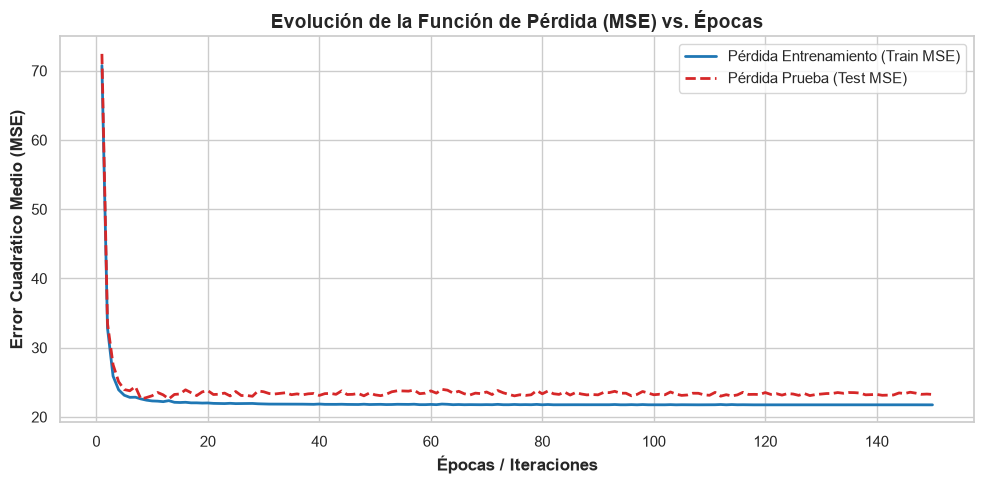

In [58]:
from sklearn.linear_model import SGDRegressor

# Instanciamos el modelo sin penalización para aislar el método de optimización
sgd = SGDRegressor(
    loss="squared_error",
    penalty=None,
    learning_rate="invscaling",
    eta0=0.01,
    power_t=0.25,
    random_state=RANDOM_STATE,
)

n_epochs = 150
mse_train_history = []
mse_test_history = []

# Iteramos época a época para registrar el historial de pérdida
# Para SGD es recomendable desordenar los datos en cada época
rng = np.random.RandomState(RANDOM_STATE)

for epoch in range(n_epochs):
    # Mezclado aleatorio por época
    indices = rng.permutation(len(X_train_escalado))
    X_train_shuffled = X_train_escalado[indices]
    y_train_shuffled = y_train.iloc[indices]

    # Actualización iterativa
    sgd.partial_fit(X_train_shuffled, y_train_shuffled)

    # Evaluación del MSE en la época actual
    y_pred_tr = sgd.predict(X_train_escalado)
    y_pred_te = sgd.predict(X_test_escalado)

    mse_train_history.append(mean_squared_error(y_train, y_pred_tr))
    mse_test_history.append(mean_squared_error(y_test, y_pred_te))

# Predicciones finales
y_pred_train_sgd = sgd.predict(X_train_escalado)
y_pred_test_sgd = sgd.predict(X_test_escalado)

# Métricas finales
metricas_sgd = pd.DataFrame(
    {
        "train": calcular_metricas(y_train, y_pred_train_sgd),
        "test": calcular_metricas(y_test, y_pred_test_sgd),
    }
)

# Comparativa directa: OLS analítico vs. SGD en Test
comparacion_test = pd.DataFrame(
    {
        "LinearRegression (OLS)": metricas_lineal["test"],
        "SGDRegressor": metricas_sgd["test"],
        "Diferencia Absoluta": (
            metricas_lineal["test"] - metricas_sgd["test"]
        ).abs(),
    }
)

print(f"Métricas SGDRegressor:\n{metricas_sgd}")
print(f"\nComparativa en conjunto de Prueba (OLS vs SGD):\n{comparacion_test}")

# --- Gráfica Error vs. Iteraciones (Loss vs. Epochs) ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    range(1, n_epochs + 1),
    mse_train_history,
    label="Pérdida Entrenamiento (Train MSE)",
    color="#1f77b4",
    linewidth=2,
)
ax.plot(
    range(1, n_epochs + 1),
    mse_test_history,
    label="Pérdida Prueba (Test MSE)",
    color="#d62728",
    linewidth=2,
    linestyle="--",
)

ax.set_title(
    "Evolución de la Función de Pérdida (MSE) vs. Épocas",
    fontweight="bold",
    fontsize=14,
)
ax.set_xlabel("Épocas / Iteraciones", fontweight="bold")
ax.set_ylabel("Error Cuadrático Medio (MSE)", fontweight="bold")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

#### Conclusiones y Análisis de Resultados

* **¿Hubo algún cambio en el desempeño?**  
  No se observan cambios significativos respecto a la regresión lineal por mínimos cuadrados ordinarios (OLS). El valor de $R^2$, RMSE y MAE sobre el conjunto de test es prácticamente idéntico (las diferencias se encuentran en el tercer decimal). Esto se debe a que la función de costo de la regresión lineal es cuadrática y estrictamente convexa, por lo que el algoritmo de gradiente descendente converge al mismo mínimo global hallado analíticamente por la ecuación normal.

* **Comportamiento de la curva de aprendizaje (Loss vs. Epochs):**  
  * La gráfica muestra una caída abrupta del error en las primeras 20 a 30 épocas, logrando una rápida aproximación a la región de mínimo costo.  
  * A partir de la época 50 la curva se estabiliza (asíntota horizontal), reflejando una convergencia suave sin oscilaciones divergentes gracias a que las predictoras fueron previamente estandarizadas (`StandardScaler`) y al decaimiento adaptativo de la tasa de aprendizaje (`learning_rate='invscaling'`).
  * La brecha constante entre la curva de entrenamiento y la de prueba se corresponde con el error de generalización esperado; no se evidencia divergencia tardía en test, lo cual confirma la ausencia de sobreajuste severo.

## Métodos de Regularización: Ridge, Lasso y ElasticNet

La multicolinealidad observada en el análisis exploratorio (altas correlaciones entre predictoras como `RAD`–`TAX`, `NOX`–`DIS` o `AGE`–`DIS`) produce inestabilidad e inflación de varianza en los coeficientes de mínimos cuadrados ordinarios (OLS). Para mitigar este problema y controlar la complejidad del modelo, se prueban tres técnicas de regularización:

* **Ridge ($L_2$):** Agrega una penalización cuadrática sobre los coeficientes ($\alpha \sum \beta_j^2$). Reduce la varianza contrayendo suavemente los coeficientes hacia cero, ideal frente a colinealidad fuerte.
* **Lasso ($L_1$):** Agrega una penalización basada en el valor absoluto ($\alpha \sum \vert{}\beta_j\vert{}$). Al tener derivadas discontinuas en el origen, es capaz de anular coeficientes de forma exacta ($\beta_j = 0$), realizando selección automática de variables.
* **ElasticNet ($L_1 + L_2$):** Combina ambas penalizaciones mediante un balance ponderado (`l1_ratio`), reteniendo la capacidad selectiva de Lasso y la estabilidad de Ridge ante grupos de variables altamente correlacionadas.

La selección de la intensidad de regularización ($\alpha$) y del balance (`l1_ratio`) se realiza mediante validación cruzada de 5 pliegues (5-Fold CV) exclusivamente sobre el conjunto de entrenamiento para evitar fuga de información (*data leakage*).

--- Hiperparámetros Óptimos ---
Ridge     -> alpha óptimo: 1.2328
Lasso     -> alpha óptimo: 0.0010
ElasticNet-> alpha óptimo: 0.0035 | l1_ratio: 0.10

--- Comparativa de Rendimiento en Test ---
      LinearRegression (OLS)  SGDRegressor  Ridge  Lasso  ElasticNet
R2                     0.668         0.669  0.669  0.668       0.669
RMSE                   4.827         4.822  4.822  4.827       4.821
MAE                    3.448         3.439  3.441  3.447       3.441


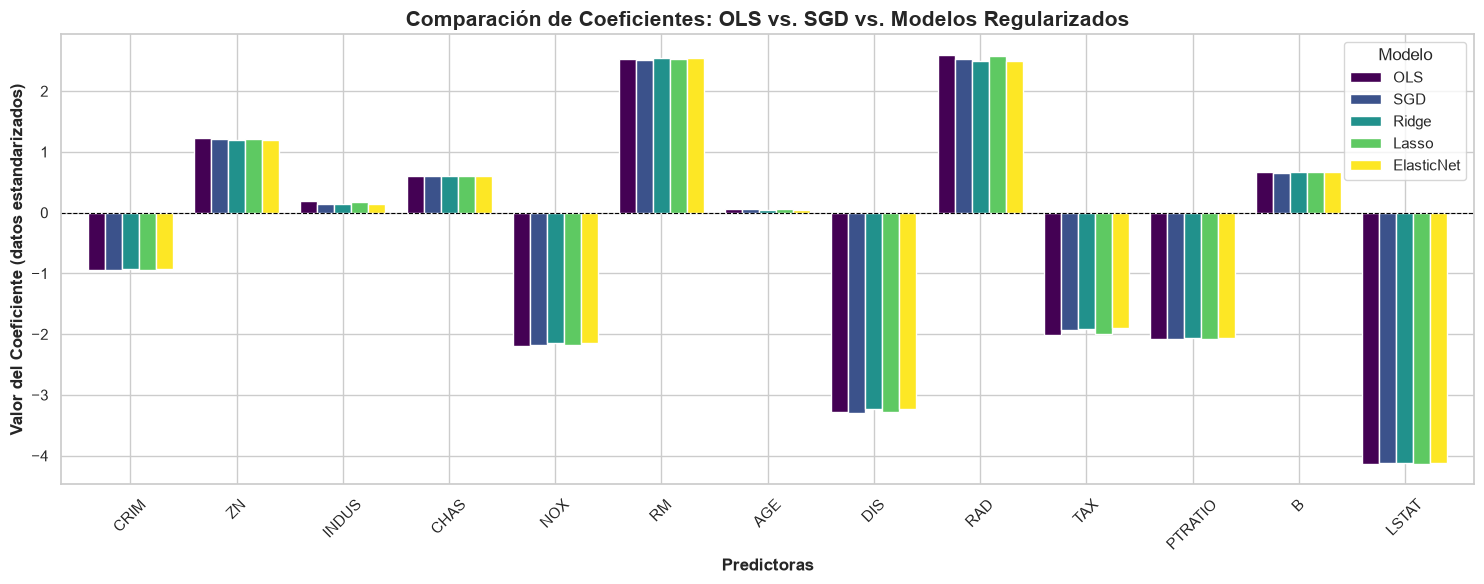

Variables anuladas exactamente por Lasso: []


In [59]:
from sklearn.linear_model import ElasticNetCV, LassoCV, RidgeCV

# Espacio de búsqueda para alpha en escala logarítmica
alphas = np.logspace(-3, 3, 100)

# 1. Ridge con validación cruzada (5 folds)
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring="neg_mean_squared_error")
ridge_cv.fit(X_train_escalado, y_train)

# 2. Lasso con validación cruzada (5 folds)
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=RANDOM_STATE, max_iter=5000)
lasso_cv.fit(X_train_escalado, y_train)

# 3. ElasticNet con validación cruzada (5 folds)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
elastic_cv = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratios,
    cv=5,
    random_state=RANDOM_STATE,
    max_iter=5000,
)
elastic_cv.fit(X_train_escalado, y_train)

# Imprimir mejores hiperparámetros encontrados
print("--- Hiperparámetros Óptimos ---")
print(f"Ridge     -> alpha óptimo: {ridge_cv.alpha_:.4f}")
print(f"Lasso     -> alpha óptimo: {lasso_cv.alpha_:.4f}")
print(
    f"ElasticNet-> alpha óptimo: {elastic_cv.alpha_:.4f} | l1_ratio: {elastic_cv.l1_ratio_:.2f}"
)

# Predicciones sobre el conjunto de prueba
y_pred_ridge = ridge_cv.predict(X_test_escalado)
y_pred_lasso = lasso_cv.predict(X_test_escalado)
y_pred_elastic = elastic_cv.predict(X_test_escalado)

# Tabla comparativa completa de métricas en Test (incluye SGD)
comparativa_regularizacion = pd.DataFrame(
    {
        "LinearRegression (OLS)": metricas_lineal["test"],
        "SGDRegressor": metricas_sgd["test"],
        "Ridge": calcular_metricas(y_test, y_pred_ridge),
        "Lasso": calcular_metricas(y_test, y_pred_lasso),
        "ElasticNet": calcular_metricas(y_test, y_pred_elastic),
    }
)

print(
    f"\n--- Comparativa de Rendimiento en Test ---\n{comparativa_regularizacion}"
)

# Comparativa de Coeficientes (incluye SGD)
df_coeficientes = pd.DataFrame(
    {
        "OLS": regresion_lineal.coef_,
        "SGD": sgd.coef_,
        "Ridge": ridge_cv.coef_,
        "Lasso": lasso_cv.coef_,
        "ElasticNet": elastic_cv.coef_,
    },
    index=X_train.columns,
)

# Gráfica de Coeficientes por Modelo
fig, ax = plt.subplots(figsize=(15, 6))
df_coeficientes.plot(kind="bar", ax=ax, width=0.8, colormap="viridis")
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title(
    "Comparación de Coeficientes: OLS vs. SGD vs. Modelos Regularizados",
    fontweight="bold",
    fontsize=15,
)
ax.set_ylabel("Valor del Coeficiente (datos estandarizados)", fontweight="bold")
ax.set_xlabel("Predictoras", fontweight="bold")
ax.legend(title="Modelo", frameon=True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Variables eliminadas por Lasso (coeficiente == 0)
variables_anuladas = df_coeficientes[df_coeficientes["Lasso"] == 0].index.tolist()
print(f"Variables anuladas exactamente por Lasso: {variables_anuladas}")

#### Análisis de Resultados de la Regularización

1. **Desempeño predictivo en Test:**  
   Las métricas de evaluación sobre datos no vistos ($R^2 \approx 0.669$, $\text{RMSE} \approx 4.82$, $\text{MAE} \approx 3.44$) son prácticamente idénticas entre OLS, Ridge, Lasso y ElasticNet. La regularización no produce una ganancia apreciable en capacidad de generalización en este escenario.

2. **Comportamiento de los Hiperparámetros y Coeficientes:**
   * **Intensidad de regularización ($\alpha$):** La validación cruzada seleccionó valores de $\alpha$ extremadamente bajos para Lasso ($0.0010$) y ElasticNet ($0.0035$), coincidiendo con el extremo inferior del espacio de búsqueda. En ElasticNet, además, el `l1_ratio` óptimo fue de $0.10$, inclinándose fuertemente hacia una penalización tipo $L_2$.
   * **Ausencia de selección de variables:** Debido a que el $\alpha$ óptimo de Lasso es casi nulo, el modelo no forzó ningún coeficiente a cero exacto. Las magnitudes de los pesos son prácticamente indistinguibles de los coeficientes de mínimos cuadrados ordinarios (OLS).

3. **Interpretación del resultado:**  
   Este comportamiento es esperable: con $N = 404$ observaciones de entrenamiento y únicamente $p = 13$ características, el espacio de parámetros está ampliamente sobredeterminado por los datos. OLS no exhibe un sobreajuste severo que requiera contracción forzada de varianza o eliminación de dimensiones, por lo que la optimización por validación cruzada prefiere retener la solución lineal clásica prácticamente sin penalizar.